# Phase 2 — Exploratory Data Analysis
## Healthcare AI System

**Input:**  `outputs/model_table.csv` — 25,000 rows, 20 columns  
**Output:** Engineered `model_table.csv` ready for Phase 3 Modeling

## EDA Philosophy: What Architects Look For

A data scientist asks: *"What does the data look like?"*  
An architect asks: *"What will this data do to my model?"*

These are four questions every architect answers **before** touching a model:

**1. Are the labels meaningful?**  
If labels are random, no model can learn them. Period.

**2. Is there class imbalance?**  
Imbalance causes models to ignore minority classes entirely — called class collapse.

**3. Which features have real signal?**  
Correlation tells us where to focus feature engineering effort.

**4. Are outliers errors or reality?**  
In healthcare, extreme values are often the most important rows.

The answers to these four questions shape every modeling decision we make in Phase 3.

In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

In [2]:
# Load Model Tables
df = pd.read_csv("../outputs/model_table.csv")
df.shape

(25000, 20)

In [3]:
# Convert date columns 
df["registration_date"] = pd.to_datetime(df["registration_date"], errors="coerce")
df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
df["billing_date"] =pd.to_datetime(df["billing_date"], errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   patient_id            25000 non-null  int64         
 1   age                   25000 non-null  int64         
 2   gender                25000 non-null  object        
 3   city                  25000 non-null  object        
 4   insurance_provider    25000 non-null  object        
 5   chronic_flag          25000 non-null  int64         
 6   registration_date     25000 non-null  datetime64[ns]
 7   visit_id              25000 non-null  int64         
 8   visit_date            25000 non-null  datetime64[ns]
 9   department            25000 non-null  object        
 10  visit_type            25000 non-null  object        
 11  length_of_stay_hours  25000 non-null  float64       
 12  risk_score            25000 non-null  object        
 13  doctor_id       

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
patient_id,25000.0,NaN,NaN,NaN,2502.20312,1.0,1263.0,2503.0,3755.0,5000.0,1443.378814
age,25000.0,NaN,NaN,NaN,44.89464,1.0,22.0,45.0,67.0,90.0,25.858097
gender,25000,2,M,12732,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,25000,6,Bangalore,4328,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance_provider,25000,4,HealthPlus,6499,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chronic_flag,25000.0,NaN,NaN,NaN,0.49948,0.0,0.0,0.0,1.0,1.0,0.50001
registration_date,25000,NaN,NaN,NaN,2025-07-20 16:04:30.720000256,2025-01-20 00:00:00,2025-04-19 00:00:00,2025-07-18 00:00:00,2025-10-21 00:00:00,2026-01-19 00:00:00,NaN
visit_id,25000.0,NaN,NaN,NaN,12500.5,1.0,6250.75,12500.5,18750.25,25000.0,7217.022701
visit_date,25000,NaN,NaN,NaN,2025-10-20 07:55:39.647999744,2025-01-21 00:00:00,2025-09-01 00:00:00,2025-11-12 00:00:00,2025-12-27 00:00:00,2026-01-20 00:00:00,NaN
department,25000,6,General,5757,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Distribution Analysis

### Step 1 - Missing Values Analysis

First thing we always check — what is missing and why.  
Not all nulls are data errors. Some are business logic.

In [5]:
# overall null check
df.isnull().sum().sort_values(ascending=False)

payment_days            9532
approved_amount         6156
patient_id                 0
age                        0
claim_status               0
billed_amount              0
bill_id                    0
doctor_id                  0
risk_score                 0
length_of_stay_hours       0
visit_type                 0
department                 0
visit_date                 0
visit_id                   0
registration_date          0
chronic_flag               0
insurance_provider         0
city                       0
gender                     0
billing_date               0
dtype: int64

In [6]:
# Focus on key columns
df[["approved_amount", "payment_days", "length_of_stay_hours"]].isnull().sum()

approved_amount         6156
payment_days            9532
length_of_stay_hours       0
dtype: int64

### Step 2 — Business Logic Validation

Three checks before we touch any model.  
We are validating that the data makes **business sense** — not just statistical sense.

In [7]:
# Check A - Paid claims should always have an approved amount
# if this returns 0, then we are clean
df[
    (df["claim_status"] == "Paid") &
    (df["approved_amount"].isna())
].shape

(0, 20)

In [8]:
# Check B - payment days missing breakdown by claim status
df[df["payment_days"].isna()]["claim_status"].value_counts()

claim_status
Rejected    5266
Pending     4266
Name: count, dtype: int64

In [9]:
# Check C - LOS should never be negative
(df["length_of_stay_hours"]<0).sum()

np.int64(0)

### Step 3 — Distribution Analysis

We look at every important column — categorical and numeric.  
Goal: understand the shape of our data before building any model.

In [10]:
# Categorical column reports
print("======= Department================")
print(df["department"].value_counts())
print("\n======Visit Type=================")
print(df["visit_type"].value_counts())
print("\n=======Insurance provider=========")
print(df["insurance_provider"].value_counts())
print("\n=======City=======================")
print(df["city"].value_counts())

======= Department================
department
General        5757
Orthopedics    4474
Cardiology     4071
ER             3896
ICU            3415
Neurology      3387
Name: count, dtype: int64

======Visit Type=================
visit_type
OPD    14635
ER      5778
ICU     4587
Name: count, dtype: int64

=======Insurance provider=========
insurance_provider
HealthPlus    6499
CareOne       6326
SecureLife    6197
MediCareX     5978
Name: count, dtype: int64

=======City=======================
city
Bangalore    4328
Mumbai       4267
Pune         4230
Delhi        4170
Hyderabad    4129
Chennai      3876
Name: count, dtype: int64


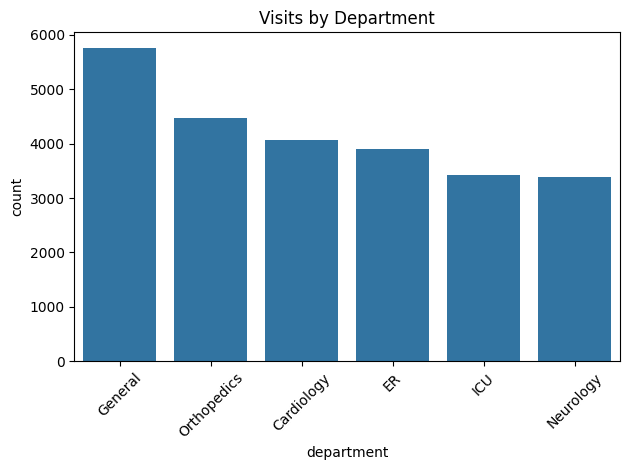

In [11]:
# Barchart showing visits by department
sns.countplot(data=df, x="department", order=df["department"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Department")
plt.tight_layout()
plt.show()

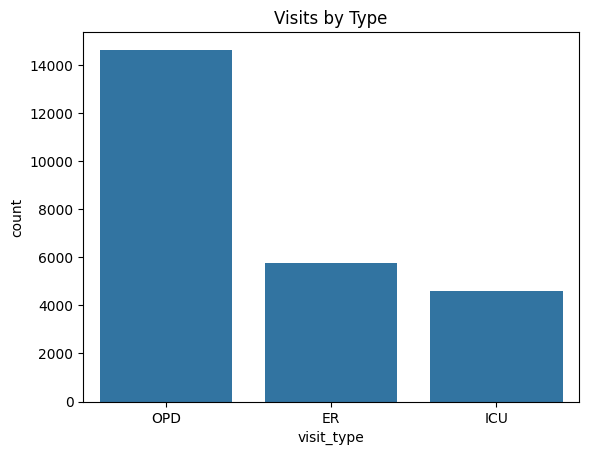

In [12]:
# Visits by Type
sns.countplot(data=df, x="visit_type", order=df["visit_type"].value_counts().index)
plt.title("Visits by Type")
plt.show()

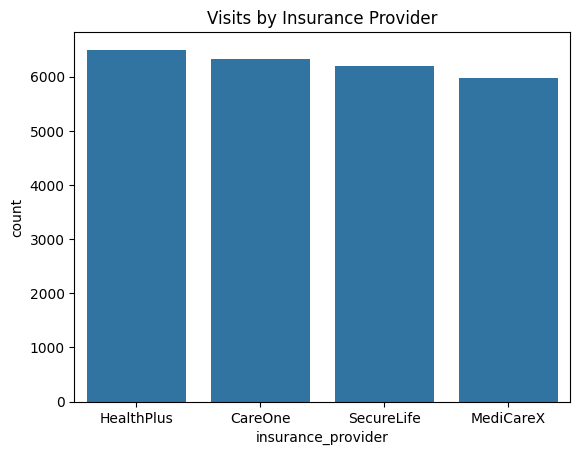

In [13]:
# Visits by Insurance Provider
sns.countplot(data=df, x="insurance_provider", order=df["insurance_provider"].value_counts().index)
plt.title("Visits by Insurance Provider")
plt.show()

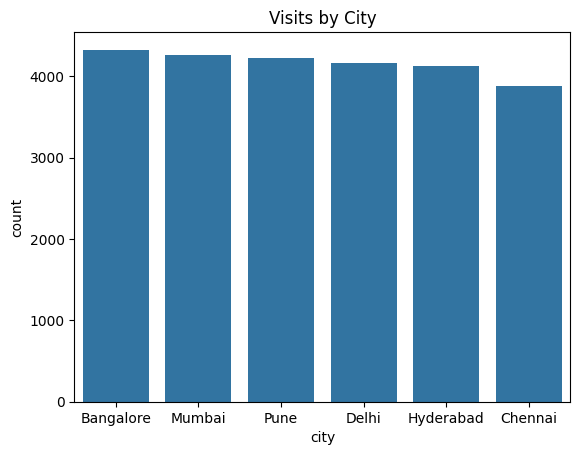

In [14]:
# Visits by City
sns.countplot(data=df, x="city", order=df["city"].value_counts().index)
plt.title("Visits by City")
plt.show()

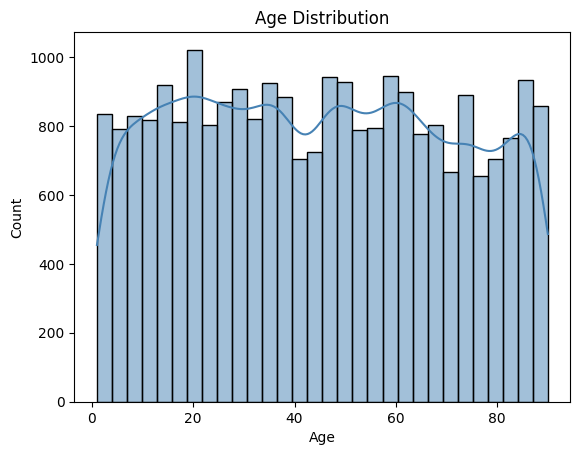

count    25000.00
mean        44.89
std         25.86
min          1.00
25%         22.00
50%         45.00
75%         67.00
max         90.00
Name: age, dtype: float64


In [15]:
# Age Dsitribution
sns.histplot(df["age"], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()
print(df["age"].describe().round(2))

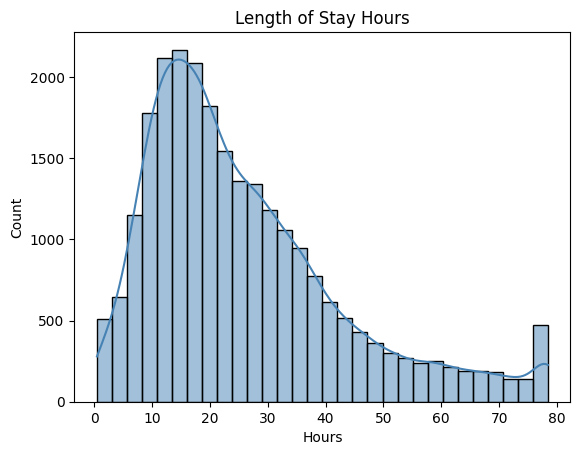

count    25000.00
mean        26.03
std         17.15
min          0.50
25%         13.54
50%         21.61
75%         34.22
max         78.42
Name: length_of_stay_hours, dtype: float64


In [16]:
# Length of Stay Distribution
sns.histplot(df["length_of_stay_hours"], bins=30, kde=True, color="steelblue")
plt.title("Length of Stay Hours")
plt.xlabel("Hours")
plt.show()
print(df["length_of_stay_hours"].describe().round(2))

In [17]:
# IQR = Interquartile Range - the spread of the middle 50% of your data
# 25% = 9.96  (bottom quarter boundary)
# 75% = 27.31 (top quarter boundary)
IQR = 27.31 - 9.96 
print(IQR)

17.349999999999998


In [18]:
# Upper Fence
# An upper fence is the cutoff, beyond which a value is considered to an outlier
# upper_fence = 75% + (1.5*IQR)
# John's variable = 1.5 (universal multiplier)

upper_fence = 27.31 + (1.5*17.35)
print(upper_fence)

53.335


## Outlier Detection

### Step 4 — Outlier Detection

Two approaches:
- **Boxplot** — visual detection
- **IQR method** — numerical calculation

**IQR = Q3 − Q1** (middle 50% of data)  
Lower bound = Q1 − 1.5 × IQR  
Upper bound = Q3 + 1.5 × IQR  

Anything outside these bounds = outlier.

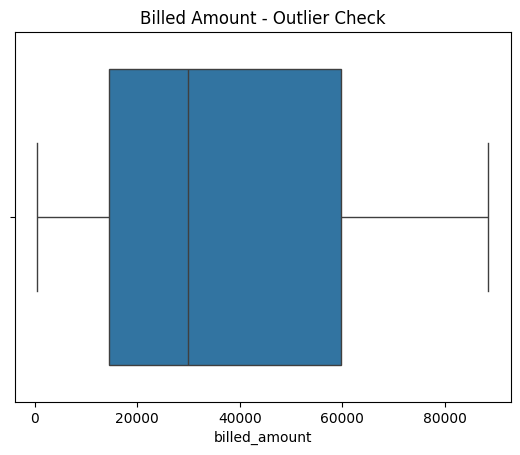

In [19]:
sns.boxplot(x=df["billed_amount"])
plt.title("Billed Amount - Outlier Check")
plt.show()

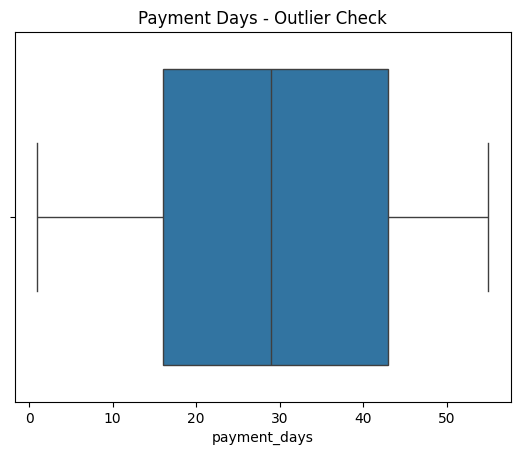

In [20]:
sns.boxplot(x=df["payment_days"])
plt.title("Payment Days - Outlier Check")
plt.show()

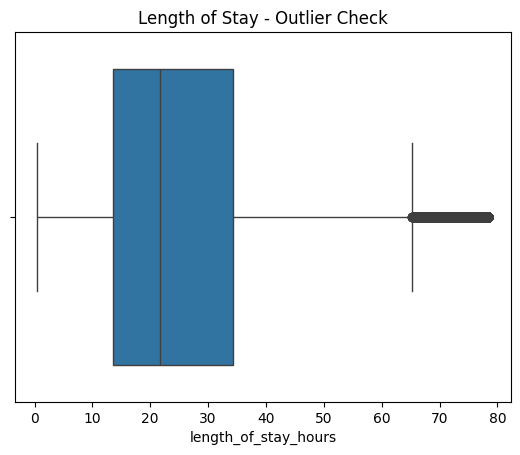

In [21]:
sns.boxplot(x=df["length_of_stay_hours"])
plt.title("Length of Stay - Outlier Check")
plt.show()

In [22]:
# IQR explicit calculation — numbers behind the boxplot
for col in ["length_of_stay_hours", "billed_amount", "payment_days"]:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}")
    print(f"  Q1 = {Q1:.1f}  |  Q3 = {Q3:.1f}  |  IQR = {IQR:.1f}")
    print(f"  Lower bound = {lower:.1f}  |  Upper bound = {upper:.1f}")
    print(f"  Outliers    = {n_out} rows")
    print()

length_of_stay_hours
  Q1 = 13.5  |  Q3 = 34.2  |  IQR = 20.7
  Lower bound = -17.5  |  Upper bound = 65.2
  Outliers    = 1136 rows

billed_amount
  Q1 = 14568.7  |  Q3 = 59710.5  |  IQR = 45141.8
  Lower bound = -53144.0  |  Upper bound = 127423.3
  Outliers    = 0 rows

payment_days
  Q1 = 16.0  |  Q3 = 43.0  |  IQR = 27.0
  Lower bound = -24.5  |  Upper bound = 83.5
  Outliers    = 0 rows



## Feature Correlations

### Step 5 — Feature Correlations

We encode the target variables numerically so we can measure correlation.

- `risk_score`  → Low=0, Medium=1, High=2
- `claim_status` → Paid=0, Pending=1, Rejected=2

In [23]:
# Encode target for correlation analysis
df["risk_numeric"] = df["risk_score"].map(
    {"Low": 0, "Medium": 1, "High": 2}
)
df["claim_numeric"] = df["claim_status"].map(
    {"Paid": 0, "Pending": 1, "Rejected": 2}
)
print("risk_numeric :",  {"Low": 0, "Medium": 1, "High": 2})
print("claim_numeric :", {"Paid": 0, "Pending": 1, "Rejected": 2})

risk_numeric : {'Low': 0, 'Medium': 1, 'High': 2}
claim_numeric : {'Paid': 0, 'Pending': 1, 'Rejected': 2}


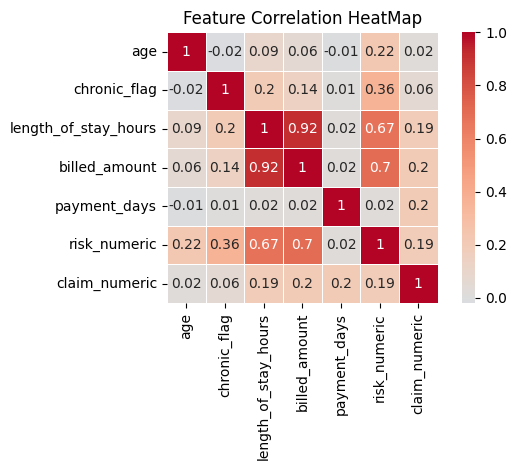

In [24]:
# Full corrleation heatmap
numeric_cols = [
    "age",
    "chronic_flag",
    "length_of_stay_hours",
    "billed_amount",
    "payment_days",
    "risk_numeric",
    "claim_numeric"
]
corr = df[numeric_cols].corr().round(2)
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, linewidth=0.5, square=True)
plt.title("Feature Correlation HeatMap")
plt.tight_layout()
plt.show()

In [25]:
# What correlates with risk_score?
corr_risk = corr["risk_numeric"].drop("risk_numeric")

print("Correlation with risk_score (sorted):")
print(corr_risk.sort_values(ascending=False).round(3))

Correlation with risk_score (sorted):
billed_amount           0.70
length_of_stay_hours    0.67
chronic_flag            0.36
age                     0.22
claim_numeric           0.19
payment_days            0.02
Name: risk_numeric, dtype: float64


In [26]:
# What correlates with claim_status?
corr_claim = corr["claim_numeric"].drop("claim_numeric")

print("Correlation with claim_status (sorted):")
print(corr_claim.sort_values(ascending=False).round(3))

Correlation with claim_status (sorted):
billed_amount           0.20
payment_days            0.20
length_of_stay_hours    0.19
risk_numeric            0.19
chronic_flag            0.06
age                     0.02
Name: claim_numeric, dtype: float64


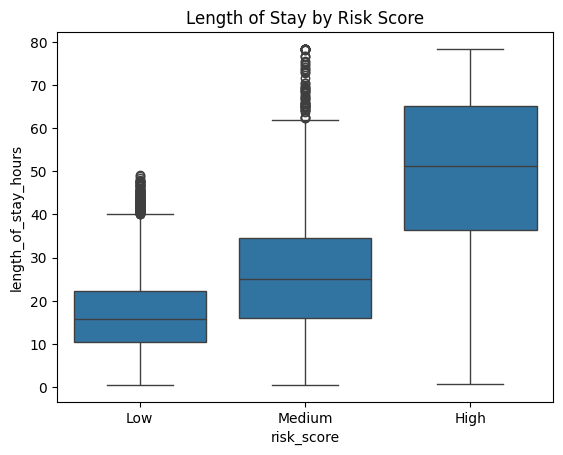


Mean LOS by Risk Score:
risk_score
High      50.69
Low       16.92
Medium    26.10
Name: length_of_stay_hours, dtype: float64


In [27]:
# LOS by risk score — the most important relationship
sns.boxplot(data=df, x="risk_score", y="length_of_stay_hours",
            order=["Low", "Medium", "High"])
plt.title("Length of Stay by Risk Score")
plt.show()

print("\nMean LOS by Risk Score:")
print(df.groupby("risk_score")["length_of_stay_hours"]
      .mean().round(2))

Rejection Rate by Insurance Provider (%):
insurance_provider
CareOne       25.7
MediCareX     24.3
HealthPlus    18.7
SecureLife    15.7
Name: is_rejected, dtype: float64


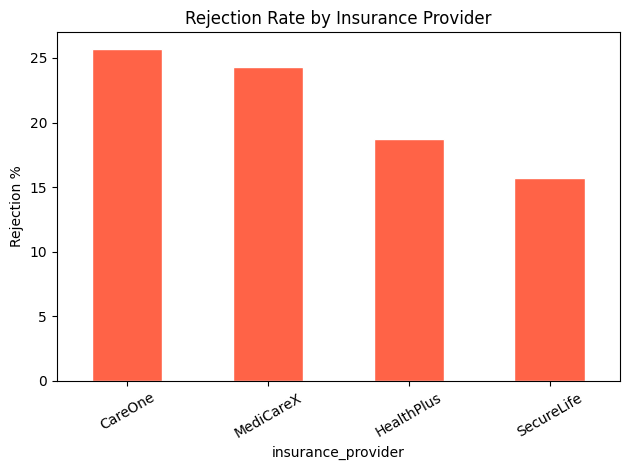

In [28]:
# Rejection rate by insurance provider
df["is_rejected"] = (df["claim_status"] == "Rejected").astype(int)

rej_rate = (df.groupby("insurance_provider")["is_rejected"]
            .mean()
            .sort_values(ascending=False)
            .mul(100)
            .round(1))

print("Rejection Rate by Insurance Provider (%):")
print(rej_rate)

rej_rate.plot(kind="bar", color="tomato", edgecolor="white")
plt.title("Rejection Rate by Insurance Provider")
plt.ylabel("Rejection %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Class Imbalance Deep Dive

### Step 6 — Class Imbalance & Class Collapse Demo

**Class imbalance** = one class has significantly more rows than others.

**Class collapse** = the model ignores minority classes and predicts 
only the majority class — achieving decent accuracy by being lazy.

We will prove this live with a before/after demo.

In [29]:
# Naive baseline - what happens if we always predict majority class

most_common = df["risk_score"].mode()[0]
naive_acc = (df["risk_score"] == most_common).mean()
print(f"Majority class: '{most_common}'") 
print(f"Naive Accuracy: '{naive_acc:.1%}'")

Majority class: 'Low'
Naive Accuracy: '46.9%'


In [30]:
# Demo setup - two features only, to keep it clean
X_demo = df[["length_of_stay_hours", "chronic_flag"]].fillna(0)
y_demo = df["risk_score"]

# without class weight
model_bad = LogisticRegression(max_iter=1000, random_state=42) # Creating the brain
model_bad.fit(X_demo, y_demo) # Training the brain
pred_bad = model_bad.predict(X_demo) # Using the brain
print("Without class_weight='balanced':")
print("-"*45)
print(classification_report(y_demo, pred_bad))
# (0.00 × 5034 + 0.50 × 12470 + 0.00 × 7496) / 25000 = weighted avg example

Without class_weight='balanced':
---------------------------------------------
              precision    recall  f1-score   support

        High       0.78      0.63      0.69      4316
         Low       0.72      0.78      0.75     11735
      Medium       0.56      0.55      0.56      8949

    accuracy                           0.67     25000
   macro avg       0.69      0.65      0.67     25000
weighted avg       0.67      0.67      0.67     25000



In [31]:
# Demo setup - two features only, to keep it clean
#X_demo = df[["length_of_stay_hours", "chronic_flag"]].fillna(0)
#y_demo = df["risk_score"]

# without class weight
model_good = LogisticRegression(max_iter=1000,class_weight="balanced", random_state=42) # Creating the brain
model_good.fit(X_demo, y_demo) # Training the brain
pred_good = model_good.predict(X_demo) # Using the brain
print("With class_weight='balanced':")
print("-"*45)
print(classification_report(y_demo, pred_good))
# (0.00 × 5034 + 0.50 × 12470 + 0.00 × 7496) / 25000 = weighted avg example

With class_weight='balanced':
---------------------------------------------
              precision    recall  f1-score   support

        High       0.62      0.74      0.67      4316
         Low       0.76      0.71      0.73     11735
      Medium       0.54      0.54      0.54      8949

    accuracy                           0.65     25000
   macro avg       0.64      0.66      0.65     25000
weighted avg       0.66      0.65      0.65     25000



In [32]:
from sklearn.metrics import recall_score

# Before — random labels (from earlier in notebook)
# After  — clinical labels (current)

recall_high_no_weight  = recall_score(y_demo, pred_bad,
                            labels=["High"], average=None)[0]
recall_high_balanced   = recall_score(y_demo, pred_good,
                            labels=["High"], average=None)[0]

print("HIGH RISK RECALL — NEW CLINICALLY-DERIVED DATA")
print("-" * 45)
print(f"Without class_weight : {recall_high_no_weight:.0%}")
print(f"With class_weight    : {recall_high_balanced:.0%}")
print()
print("COMPARISON — OLD vs NEW DATASET (with class_weight)")
print("-" * 45)
print(f"Old dataset (random labels)  : ~20%  accuracy 37%")
print(f"New dataset (clinical labels): {recall_high_balanced:.0%}  accuracy 67%")
print()
print("Same model. Same 2 features. Labels fixed.")
print("30 percentage point accuracy jump from data quality alone.")

HIGH RISK RECALL — NEW CLINICALLY-DERIVED DATA
---------------------------------------------
Without class_weight : 63%
With class_weight    : 74%

COMPARISON — OLD vs NEW DATASET (with class_weight)
---------------------------------------------
Old dataset (random labels)  : ~20%  accuracy 37%
New dataset (clinical labels): 74%  accuracy 67%

Same model. Same 2 features. Labels fixed.
30 percentage point accuracy jump from data quality alone.


## Step 7 — Feature Engineering

We create 7 new features from the existing columns.  
These features encode **patient behaviour** and **provider patterns**  
that the raw columns cannot express on their own.

| Feature | Logic | Why it matters |
|---|---|---|
| days_since_registration | visit_date − registration_date | Long-term patients behave differently |
| visit_frequency | count of visits per patient | Frequent visitors = higher utilisation |
| avg_los_per_patient | mean LOS per patient | Patient-level health baseline |
| is_rejected | 1 if Rejected else 0 | Helper for rejection rate |
| provider_rejection_rate | mean rejection per insurer | Encodes insurer behaviour |
| visit_month | month from visit_date | Seasonality signal |
| visit_dayofweek | day of week from visit_date | Operational pattern |
| high_cost_visit_flag | billed > 75th percentile | Flags expensive visits |

In [33]:
# Days since registration
df["days_since_registration"] = abs(
    df["visit_date"] - df["registration_date"]
).dt.days

df[["patient_id", "visit_date",
    "registration_date", "days_since_registration"]].head()

,patient_id,visit_date,registration_date,days_since_registration
0,2,2026-01-01,2025-12-27,5
1,12,2026-01-01,2025-08-13,141
2,129,2026-01-01,2025-07-20,165
3,133,2026-01-01,2025-11-02,60
4,139,2026-01-01,2025-02-05,330


In [34]:
# Visit frequency per patient
df["visit_frequency"] = df.groupby("patient_id")["visit_id"].transform("count")

df[["patient_id", "visit_frequency"]].drop_duplicates().head(10)

,patient_id,visit_frequency
0,2,4
1,12,8
2,129,3
3,133,3
4,139,9
5,170,6
6,216,5
7,222,5
8,243,9
9,335,5


In [35]:
# Average LOS per patient
df["avg_los_per_patient"] = df.groupby("patient_id")["length_of_stay_hours"].transform("mean")

df[["patient_id", "length_of_stay_hours",
    "avg_los_per_patient"]].head()

,patient_id,length_of_stay_hours,avg_los_per_patient
0,2,9.63,21.120000
1,12,59.60,23.750000
2,129,59.28,32.460000
3,133,25.15,30.056667
4,139,42.88,29.030000


In [36]:
# Provider rejection rate
# is_rejected already created in Cell 37
df["provider_rejection_rate"] = df.groupby("insurance_provider")["is_rejected"].transform("mean")

print("Rejection rate per provider:")
print(df.groupby("insurance_provider")["provider_rejection_rate"]
      .first().round(3))

Rejection rate per provider:
insurance_provider
CareOne       0.257
HealthPlus    0.187
MediCareX     0.243
SecureLife    0.157
Name: provider_rejection_rate, dtype: float64


In [37]:
# Time-based features
df["visit_month"]      = df["visit_date"].dt.month
df["visit_dayofweek"]  = df["visit_date"].dt.dayofweek

df[["visit_date", "visit_month", "visit_dayofweek"]].head()

,visit_date,visit_month,visit_dayofweek
0,2026-01-01,1,3
1,2026-01-01,1,3
2,2026-01-01,1,3
3,2026-01-01,1,3
4,2026-01-01,1,3


In [38]:
# High cost visit flag — top 25% of billed amount
high_cost_threshold = df["billed_amount"].quantile(0.75)
df["high_cost_visit_flag"] = (df["billed_amount"] > high_cost_threshold).astype(int)

print(f"High cost threshold (75th percentile): ₹{high_cost_threshold:,.0f}")
print()
print(df["high_cost_visit_flag"].value_counts())

High cost threshold (75th percentile): ₹59,711

high_cost_visit_flag
0    18750
1     6250
Name: count, dtype: int64


In [39]:
# Final feature check
new_features = [
    "days_since_registration",
    "visit_frequency",
    "avg_los_per_patient",
    "provider_rejection_rate",
    "visit_month",
    "visit_dayofweek",
    "high_cost_visit_flag"
]

print("New features added:")
for f in new_features:
    print(f"  ✓ {f}")

print(f"\nFinal dataset shape: {df.shape}")

New features added:
  ✓ days_since_registration
  ✓ visit_frequency
  ✓ avg_los_per_patient
  ✓ provider_rejection_rate
  ✓ visit_month
  ✓ visit_dayofweek
  ✓ high_cost_visit_flag

Final dataset shape: (25000, 30)


In [40]:
df[new_features].describe().round(2)

,days_since_registration,visit_frequency,avg_los_per_patient,provider_rejection_rate,visit_month,visit_dayofweek,high_cost_visit_flag
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00,25000.00
mean,91.66,6.04,26.03,0.21,7.57,2.98,0.25
std,80.65,2.39,8.48,0.04,4.10,2.02,0.43
min,1.00,1.00,0.50,0.16,1.00,0.00,0.00
25%,25.00,4.00,20.06,0.19,4.00,1.00,0.00
50%,69.00,6.00,25.13,0.19,9.00,3.00,0.00
75%,140.00,8.00,30.82,0.26,11.00,5.00,0.25
max,363.00,14.00,78.42,0.26,12.00,6.00,1.00


In [41]:
# Save enriched model_table — ready for Phase 3 Modeling
df.to_csv("../outputs/model_table.csv", index=False)

print("model_table.csv saved ✓")
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nReady for Phase 3 — Modeling")

model_table.csv saved ✓
Shape  : (25000, 30)
Columns: ['patient_id', 'age', 'gender', 'city', 'insurance_provider', 'chronic_flag', 'registration_date', 'visit_id', 'visit_date', 'department', 'visit_type', 'length_of_stay_hours', 'risk_score', 'doctor_id', 'bill_id', 'billed_amount', 'approved_amount', 'claim_status', 'payment_days', 'billing_date', 'risk_numeric', 'claim_numeric', 'is_rejected', 'days_since_registration', 'visit_frequency', 'avg_los_per_patient', 'provider_rejection_rate', 'visit_month', 'visit_dayofweek', 'high_cost_visit_flag']

Ready for Phase 3 — Modeling
